<a href="https://colab.research.google.com/github/sorotdaniel/portfolio-soro/blob/main/seance10(Nettoyage%20et%20transformation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1- Nettayage des chaines

# documentation: https://docs.python.org/fr/3/tutorial/

# Suppimer/remplacer les symboles

In [2]:
prix = {'prix': ['1,200.50 €','1,500.75€', '$ 850,00', 'Gratuit'],
        'remise': ['10%','10%', '5 %', 'N/A']}
df3 = pd.DataFrame(prix)
df3

,prix,remise
0,"1,200.50 €",10%
1,"1,500.75€",10%
2,"$ 850,00",5 %
3,Gratuit,N/A


In [3]:
df3['prix']= df3['prix'].str.replace('$','').str.replace('€','').str.replace(',','').str.replace('Gratuit','0')
df3

,prix,remise
0,1200.50,10%
1,1500.75,10%
2,85000,5 %
3,0,N/A


In [4]:
df3['prix'].astype(float)

,prix
0,1200.50
1,1500.75
2,85000.00
3,0.00


# Dates et temps

In [5]:
import pandas as pd

data = {'date_transaction': ['2023-10-27','2024-05-25','2024-01-02', '28/10/2023', 'Oct 29, 2023', 'invalid_date'],
        'montant': [100,215,175, 150, 200, 50]}
df = pd.DataFrame(data)
print(df.dtypes)

date_transaction    object
montant              int64
dtype: object


In [6]:
df

,date_transaction,montant
0,2023-10-27,100
1,2024-05-25,215
2,2024-01-02,175
3,28/10/2023,150
4,"Oct 29, 2023",200
5,invalid_date,50


In [7]:
df['date_trans'] = pd.to_datetime(df['date_transaction'], errors ='coerce')

In [8]:
df

,date_transaction,montant,date_trans
0,2023-10-27,100,2023-10-27
1,2024-05-25,215,2024-05-25
2,2024-01-02,175,2024-01-02
3,28/10/2023,150,NaT
4,"Oct 29, 2023",200,NaT
5,invalid_date,50,NaT


In [9]:
df['date_trans'] = pd.to_datetime(df['date_transaction'], format='%d/%m/%Y', errors='coerce')

In [10]:
df

,date_transaction,montant,date_trans
0,2023-10-27,100,NaT
1,2024-05-25,215,NaT
2,2024-01-02,175,NaT
3,28/10/2023,150,2023-10-28
4,"Oct 29, 2023",200,NaT
5,invalid_date,50,NaT


#II- cas pratique

In [11]:
df = pd.read_csv('dataset_transformation.csv', index_col='ID')

In [12]:
df

,Nom,Âge,Salaire,Date_Embauche,Ville
ID,,,,,
1,grace,64.0,$-500,28/10/2023,Toronto
2,DAVID,29.0,NaN,15-08-2022,Halifax
3,eve,33.0,$-500,NaN,NaN
4,grace,41.0,$4500,2023-10-27,Québec
5,charlie,36.0,$4000,NaT,NaN
...,...,...,...,...,...
1996,Alice,42.0,$2500,2023-10-27,NaN
1997,Bob,57.0,$2500,2023-10-27,Vancouver
1998,Alice,41.0,$4500,2023-10-27,Québec


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 1 to 2000
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nom            2000 non-null   object 
 1   Âge            1968 non-null   float64
 2   Salaire        1810 non-null   object 
 3   Date_Embauche  1693 non-null   object 
 4   Ville          1457 non-null   object 
dtypes: float64(1), object(4)
memory usage: 93.8+ KB


In [14]:
for col in df.columns:
  df[col].value_counts()

# variable Nom

In [15]:
df['Nom'].isna().sum()

np.int64(0)

In [16]:
df['Nom'] = df['Nom'].str.capitalize()
df

,Nom,Âge,Salaire,Date_Embauche,Ville
ID,,,,,
1,Grace,64.0,$-500,28/10/2023,Toronto
2,David,29.0,NaN,15-08-2022,Halifax
3,Eve,33.0,$-500,NaN,NaN
4,Grace,41.0,$4500,2023-10-27,Québec
5,Charlie,36.0,$4000,NaT,NaN
...,...,...,...,...,...
1996,Alice,42.0,$2500,2023-10-27,NaN
1997,Bob,57.0,$2500,2023-10-27,Vancouver
1998,Alice,41.0,$4500,2023-10-27,Québec


#2-Variable Âge

In [17]:
df.columns=df.columns.str.lower()
df.columns

Index(['nom', 'âge', 'salaire', 'date_embauche', 'ville'], dtype='object')

In [18]:
df.columns=df.columns.str.replace('â','a')
df.columns

Index(['nom', 'age', 'salaire', 'date_embauche', 'ville'], dtype='object')

In [19]:
for col in df.columns:
  df[col].value_counts()
  print(col ,df[col].isna().sum()*100 / len(df),'%')

nom 0.0 %
age 1.6 %
salaire 9.5 %
date_embauche 15.35 %
ville 27.15 %


In [20]:
df['age'].fillna(df['age'].mean())
df['age'].isna().sum()

np.int64(32)

In [21]:
df['age'].value_counts()


,count
age,
38.0,53
42.0,48
32.0,48
52.0,47
25.0,45
51.0,44
23.0,43
49.0,42
21.0,42


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df['age' ].skew()

np.float64(6.39679710104672)

<Axes: >

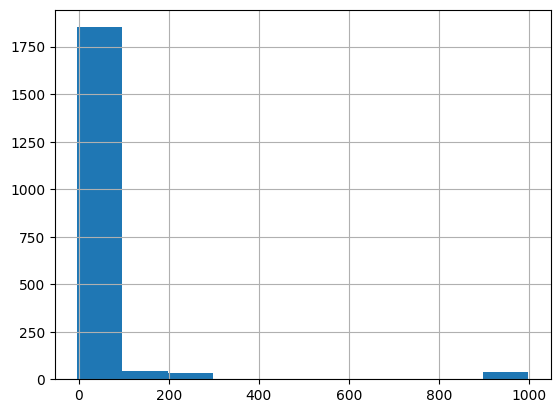

In [24]:
df['age'].hist()

<Axes: xlabel='age'>

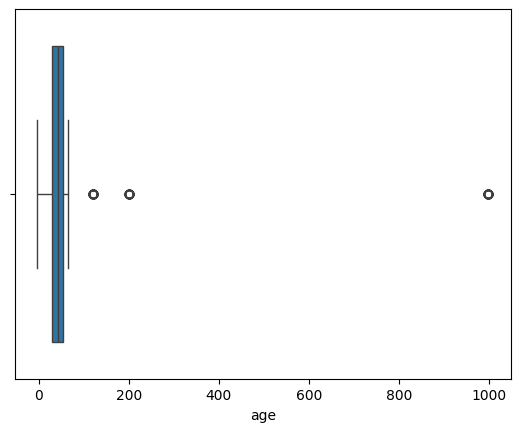

In [25]:
sns.boxplot(x=df['age'],data=df)

In [26]:
'''lower, upper = df['age'].quantile([0.02,0.95])
df['age'] = df['age'].clip(lower, upper)
print(lower,upper)
'''

"lower, upper = df['age'].quantile([0.02,0.95])\ndf['age'] = df['age'].clip(lower, upper)\nprint(lower,upper)\n"

<Axes: xlabel='age'>

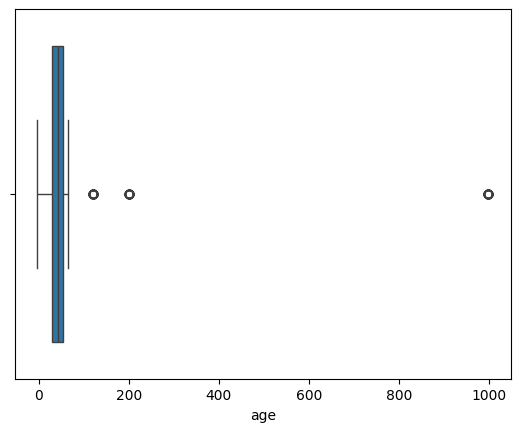

In [27]:
sns.boxplot(x=df['age'],data=df)

In [28]:
df.loc[df['age']<15,'age']=15
df.loc[df['age']>75,'age']=75

<Axes: xlabel='age'>

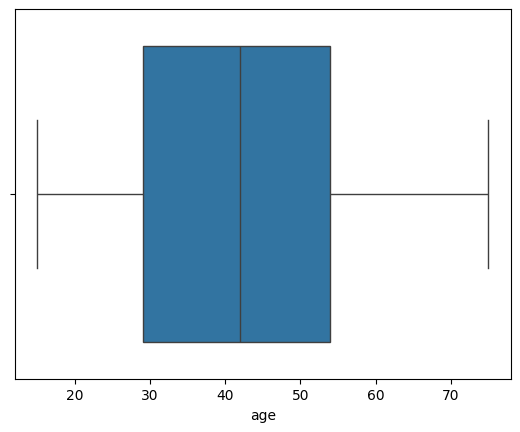

In [29]:
sns.boxplot(x=df['age'],data=df)

In [30]:
import scipy
df['age'] = scipy.stats.mstats.winsorize(df['age'])
df

,nom,age,salaire,date_embauche,ville
ID,,,,,
1,Grace,64.0,$-500,28/10/2023,Toronto
2,David,29.0,NaN,15-08-2022,Halifax
3,Eve,33.0,$-500,NaN,NaN
4,Grace,41.0,$4500,2023-10-27,Québec
5,Charlie,36.0,$4000,NaT,NaN
...,...,...,...,...,...
1996,Alice,42.0,$2500,2023-10-27,NaN
1997,Bob,57.0,$2500,2023-10-27,Vancouver
1998,Alice,41.0,$4500,2023-10-27,Québec


In [31]:
df['age_group'] = pd.cut(df['age'],bins=[15,25,40,55,75],labels=['Generation_Z','Generation_Y', 'genration_X','baby_boomers'])

In [32]:
df

,nom,age,salaire,date_embauche,ville,age_group
ID,,,,,,
1,Grace,64.0,$-500,28/10/2023,Toronto,baby_boomers
2,David,29.0,NaN,15-08-2022,Halifax,Generation_Y
3,Eve,33.0,$-500,NaN,NaN,Generation_Y
4,Grace,41.0,$4500,2023-10-27,Québec,genration_X
5,Charlie,36.0,$4000,NaT,NaN,Generation_Y
...,...,...,...,...,...,...
1996,Alice,42.0,$2500,2023-10-27,NaN,genration_X
1997,Bob,57.0,$2500,2023-10-27,Vancouver,baby_boomers
1998,Alice,41.0,$4500,2023-10-27,Québec,genration_X


In [33]:
df.groupby(df['age_group'],as_index=False).count()

/tmp/ipykernel_1108/1901962290.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['age_group'],as_index=False).count()


,age_group,nom,age,salaire,date_embauche,ville
0,Generation_Z,301,301,270,250,217
1,Generation_Y,584,584,529,493,432
2,genration_X,576,576,520,486,420
3,baby_boomers,448,448,410,389,322


<Axes: >

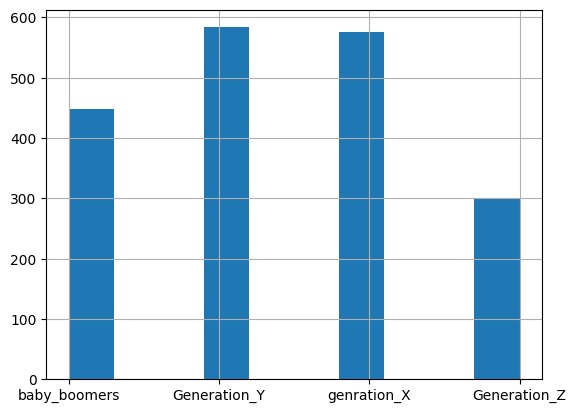

In [34]:
df['age_group'].hist()

# 3-variable salaire


In [35]:
df.head(50)

,nom,age,salaire,date_embauche,ville,age_group
ID,,,,,,
1,Grace,64.0,$-500,28/10/2023,Toronto,baby_boomers
2,David,29.0,NaN,15-08-2022,Halifax,Generation_Y
3,Eve,33.0,$-500,NaN,NaN,Generation_Y
4,Grace,41.0,$4500,2023-10-27,Québec,genration_X
5,Charlie,36.0,$4000,NaT,NaN,Generation_Y
6,Heidi,25.0,$4000,NaT,Québec,Generation_Z
7,Eve,48.0,$4000,"Oct 29, 2023",NaN,genration_X
8,Eve,38.0,$100000,15-08-2022,Montréal,Generation_Y
9,Grace,34.0,$4000,NaT,NaN,Generation_Y


In [36]:
df['salaire'] = df['salaire'].str.replace('$','').str.replace('-','').str.strip()

In [37]:
df

,nom,age,salaire,date_embauche,ville,age_group
ID,,,,,,
1,Grace,64.0,500,28/10/2023,Toronto,baby_boomers
2,David,29.0,NaN,15-08-2022,Halifax,Generation_Y
3,Eve,33.0,500,NaN,NaN,Generation_Y
4,Grace,41.0,4500,2023-10-27,Québec,genration_X
5,Charlie,36.0,4000,NaT,NaN,Generation_Y
...,...,...,...,...,...,...
1996,Alice,42.0,2500,2023-10-27,NaN,genration_X
1997,Bob,57.0,2500,2023-10-27,Vancouver,baby_boomers
1998,Alice,41.0,4500,2023-10-27,Québec,genration_X


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 1 to 2000
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   nom            2000 non-null   object  
 1   age            1968 non-null   float64 
 2   salaire        1810 non-null   object  
 3   date_embauche  1693 non-null   object  
 4   ville          1457 non-null   object  
 5   age_group      1909 non-null   category
dtypes: category(1), float64(1), object(4)
memory usage: 95.9+ KB


In [39]:
df['salaire'] = df['salaire'].astype(float)

In [40]:
df.describe()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,age,salaire
count,1968.000000,1810.000000
mean,42.198679,13637.569061
std,15.847637,29516.387081
min,15.000000,500.000000
25%,29.000000,2500.000000
50%,42.000000,3500.000000
75%,54.000000,4500.000000
max,75.000000,100000.000000


In [41]:
df.groupby(df['salaire'],as_index=False).count()

,salaire,nom,age,date_embauche,ville,age_group
0,500.0,215,211,179,168,204
1,1500.0,195,190,166,147,184
2,2500.0,220,219,187,152,214
3,3000.0,178,175,154,130,169
4,3500.0,216,214,185,150,206
5,4000.0,206,203,169,149,198
6,4500.0,200,196,169,145,192
7,10000.0,192,188,157,140,183
8,100000.0,188,186,161,140,179


# villes

In [42]:
df['ville'].value_counts()

,count
ville,
Toronto,339
Halifax,302
Québec,283
Montréal,271
Vancouver,262


In [43]:
df['ville'].isna().sum()

np.int64(543)

In [44]:
df['ville'].fillna('Inconnu',inplace=True)

/tmp/ipykernel_1108/2503420754.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ville'].fillna('Inconnu',inplace=True)


In [45]:
df['salaire'] = df['salaire'].fillna(df['salaire'].median())
df['salaire'] = df['salaire'].astype(float)
df.groupby(['ville'])['salaire'].mean()

,salaire
ville,
Halifax,12011.589404
Inconnu,12200.736648
Montréal,16841.328413
Québec,11952.296820
Toronto,11672.566372
Vancouver,12187.022901


# Date d'embauche

In [46]:
df['date_embauche'].value_counts()

,count
date_embauche,
NaT,292
28/10/2023,290
"Oct 29, 2023",282
15-08-2022,281
2023-10-27,275
2023/09/15,273


In [47]:
def parse_date(x):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%b %d, %Y","%d-%m-%Y","%Y/%m/%d"):
        try:
            return pd.to_datetime(x, format=fmt)
        except:
            continue
    return pd.NaT  # Si aucun format ne marche

df["date_parsed"] = df["date_embauche"].apply(parse_date)

In [48]:
df

,nom,age,salaire,date_embauche,ville,age_group,date_parsed
ID,,,,,,,
1,Grace,64.0,500.0,28/10/2023,Toronto,baby_boomers,2023-10-28
2,David,29.0,3500.0,15-08-2022,Halifax,Generation_Y,2022-08-15
3,Eve,33.0,500.0,NaN,Inconnu,Generation_Y,NaT
4,Grace,41.0,4500.0,2023-10-27,Québec,genration_X,2023-10-27
5,Charlie,36.0,4000.0,NaT,Inconnu,Generation_Y,NaT
...,...,...,...,...,...,...,...
1996,Alice,42.0,2500.0,2023-10-27,Inconnu,genration_X,2023-10-27
1997,Bob,57.0,2500.0,2023-10-27,Vancouver,baby_boomers,2023-10-27
1998,Alice,41.0,4500.0,2023-10-27,Québec,genration_X,2023-10-27


In [49]:
#df['date_parsed'] = df['date_parsed'].fillna(df['date_parsed'].median(),inplace=True)
mode_date = df['date_parsed'].mode()[0]
df['date_parsed'] = df['date_parsed'].fillna(mode_date)

In [50]:
df

,nom,age,salaire,date_embauche,ville,age_group,date_parsed
ID,,,,,,,
1,Grace,64.0,500.0,28/10/2023,Toronto,baby_boomers,2023-10-28
2,David,29.0,3500.0,15-08-2022,Halifax,Generation_Y,2022-08-15
3,Eve,33.0,500.0,NaN,Inconnu,Generation_Y,2023-10-28
4,Grace,41.0,4500.0,2023-10-27,Québec,genration_X,2023-10-27
5,Charlie,36.0,4000.0,NaT,Inconnu,Generation_Y,2023-10-28
...,...,...,...,...,...,...,...
1996,Alice,42.0,2500.0,2023-10-27,Inconnu,genration_X,2023-10-27
1997,Bob,57.0,2500.0,2023-10-27,Vancouver,baby_boomers,2023-10-27
1998,Alice,41.0,4500.0,2023-10-27,Québec,genration_X,2023-10-27


In [51]:
# Extraction de caracteristiques
df['année_emb']=df['date_parsed'].dt.year
df['mois_emb']=df['date_parsed'].dt.month
df['jour_emb']=df['date_parsed'].dt.day


In [52]:
df.drop(columns=['date_embauche'],inplace=True)

In [53]:
df

,nom,age,salaire,ville,age_group,date_parsed,année_emb,mois_emb,jour_emb
ID,,,,,,,,,
1,Grace,64.0,500.0,Toronto,baby_boomers,2023-10-28,2023,10,28
2,David,29.0,3500.0,Halifax,Generation_Y,2022-08-15,2022,8,15
3,Eve,33.0,500.0,Inconnu,Generation_Y,2023-10-28,2023,10,28
4,Grace,41.0,4500.0,Québec,genration_X,2023-10-27,2023,10,27
5,Charlie,36.0,4000.0,Inconnu,Generation_Y,2023-10-28,2023,10,28
...,...,...,...,...,...,...,...,...,...
1996,Alice,42.0,2500.0,Inconnu,genration_X,2023-10-27,2023,10,27
1997,Bob,57.0,2500.0,Vancouver,baby_boomers,2023-10-27,2023,10,27
1998,Alice,41.0,4500.0,Québec,genration_X,2023-10-27,2023,10,27


In [54]:
df['mois_emb'].value_counts()

,count
mois_emb,
10,1446
8,281
9,273


# Synthèse des données


In [55]:
df.describe()

,age,salaire,date_parsed,année_emb,mois_emb,jour_emb
count,1968.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000
mean,42.198679,12674.500000,2023-08-21 10:54:28.800000,2022.859500,9.582500,24.402500
min,15.000000,500.000000,2022-08-15 00:00:00,2022.000000,8.000000,15.000000
25%,29.000000,2500.000000,2023-09-15 00:00:00,2023.000000,9.000000,15.000000
50%,42.000000,3500.000000,2023-10-28 00:00:00,2023.000000,10.000000,28.000000
75%,54.000000,4500.000000,2023-10-28 00:00:00,2023.000000,10.000000,28.000000
max,75.000000,100000.000000,2023-10-29 00:00:00,2023.000000,10.000000,29.000000
std,15.847637,28235.618903,NaN,0.347592,0.724193,5.845218


In [56]:
df.describe(include='all')

,nom,age,salaire,ville,age_group,date_parsed,année_emb,mois_emb,jour_emb
count,2000,1968.000000,2000.000000,2000,1909,2000,2000.000000,2000.000000,2000.000000
unique,8,NaN,NaN,6,4,NaN,NaN,NaN,NaN
top,Alice,NaN,NaN,Inconnu,Generation_Y,NaN,NaN,NaN,NaN
freq,270,NaN,NaN,543,584,NaN,NaN,NaN,NaN
mean,NaN,42.198679,12674.500000,NaN,NaN,2023-08-21 10:54:28.800000,2022.859500,9.582500,24.402500
min,NaN,15.000000,500.000000,NaN,NaN,2022-08-15 00:00:00,2022.000000,8.000000,15.000000
25%,NaN,29.000000,2500.000000,NaN,NaN,2023-09-15 00:00:00,2023.000000,9.000000,15.000000
50%,NaN,42.000000,3500.000000,NaN,NaN,2023-10-28 00:00:00,2023.000000,10.000000,28.000000
75%,NaN,54.000000,4500.000000,NaN,NaN,2023-10-28 00:00:00,2023.000000,10.000000,28.000000
max,NaN,75.000000,100000.000000,NaN,NaN,2023-10-29 00:00:00,2023.000000,10.000000,29.000000


## Tableaux corisés: crosstab


In [57]:
pd.crosstab(df['ville'], df['age_group'])

age_group,Generation_Z,Generation_Y,genration_X,baby_boomers
ville,,,,
Halifax,43,90,85,70
Inconnu,84,152,156,126
Montréal,48,66,84,57
Québec,35,86,91,60
Toronto,47,114,87,71
Vancouver,44,76,73,64


## Tableaux corisés: Groupby

In [58]:
df.groupby(['ville', 'age_group']).nom.count()

/tmp/ipykernel_1108/568705789.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['ville', 'age_group']).nom.count()


ville      age_group   
Halifax    Generation_Z     43
           Generation_Y     90
           genration_X      85
           baby_boomers     70
Inconnu    Generation_Z     84
           Generation_Y    152
           genration_X     156
           baby_boomers    126
Montréal   Generation_Z     48
           Generation_Y     66
           genration_X      84
           baby_boomers     57
Québec     Generation_Z     35
           Generation_Y     86
           genration_X      91
           baby_boomers     60
Toronto    Generation_Z     47
           Generation_Y    114
           genration_X      87
           baby_boomers     71
Vancouver  Generation_Z     44
           Generation_Y     76
           genration_X      73
           baby_boomers     64
Name: nom, dtype: int64

In [59]:
#df.groupby('ville')['salaire'].mean()
df.groupby(['ville', 'age_group']).agg({'salaire':['mean', 'min' ,'max','count']})


/tmp/ipykernel_1108/2154325545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['ville', 'age_group']).agg({'salaire':['mean', 'min' ,'max','count']})


salaire                       
                                mean    min       max count
ville     age_group                                        
Halifax   Generation_Z  10662.790698  500.0  100000.0    43
          Generation_Y  14372.222222  500.0  100000.0    90
          genration_X   12994.117647  500.0  100000.0    85
          baby_boomers   8842.857143  500.0  100000.0    70
Inconnu   Generation_Z  10589.285714  500.0  100000.0    84
          Generation_Y  10608.552632  500.0  100000.0   152
          genration_X   14253.205128  500.0  100000.0   156
          baby_boomers  12833.333333  500.0  100000.0   126
Montréal  Generation_Z  15312.500000  500.0  100000.0    48
          Generation_Y  19598.484848  500.0  100000.0    66
          genration_X   11398.809524  500.0  100000.0    84
          baby_boomers  23394.736842  500.0  100000.0    57
Québec    Generation_Z  17614.285714  500.0  100000.0    35
          Generation_Y  11593.023256  500.0  100000.0    86
          genration_X   12313.186813  500.0  100000.0    91
          baby_boomers  10083.333333  500.0  100000.0    60
Toronto   Generation_Z  13946.808511  500.0  100000.0    47
          Generation_Y  11412.280702  500.0  100000.0   114
          genration_X   12482.758621  500.0  100000.0    87
          baby_boomers   6521.126761  500.0  100000.0    71
Vancouver Generation_Z  10056.818182  500.0  100000.0    44
          Generation_Y  12440.789474  500.0  100000.0    76
          genration_X   11020.547945  500.0  100000.0    73
          baby_boomers  15351.562500  500.0  100000.0    64

<Axes: xlabel='ville', ylabel='age'>

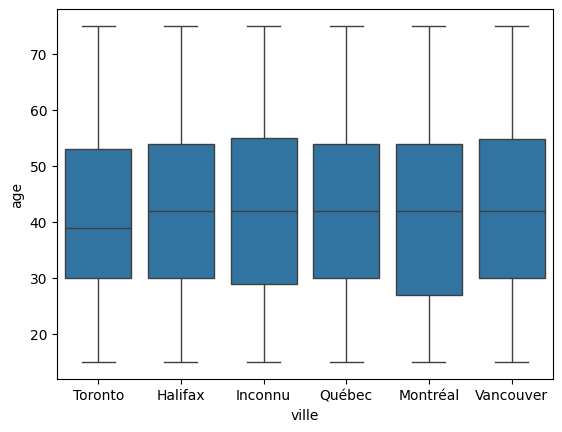

In [60]:
sns.boxplot(x=df['ville'],y=df['age'],data=df)

<Axes: xlabel='ville', ylabel='salaire'>

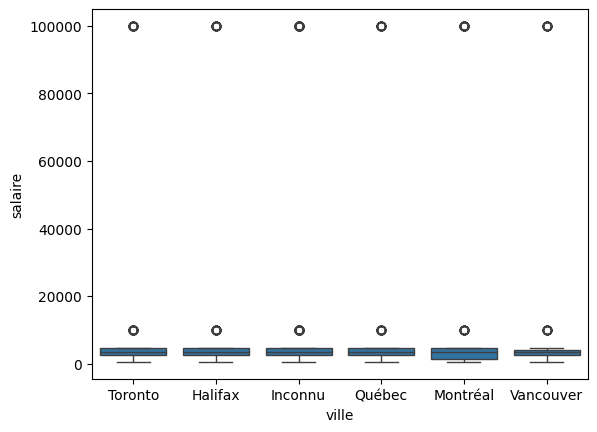

In [61]:
	import seaborn as sns
	sns.boxplot(x='ville', y='salaire', data=df)

<Axes: ylabel='count'>

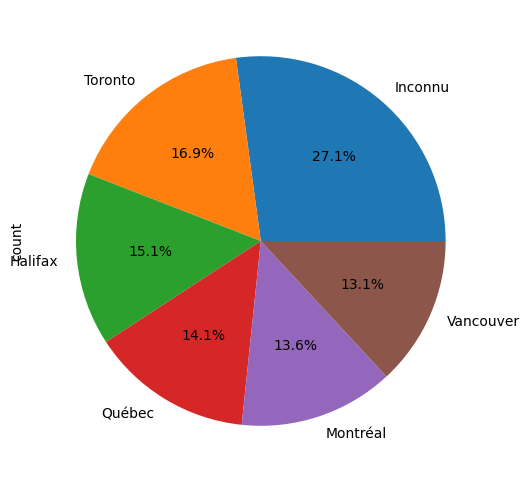

In [62]:
df['ville'].value_counts().plot(kind='pie', autopct='%1.1f%%',figsize=(8,6))

<Axes: xlabel='age_group'>

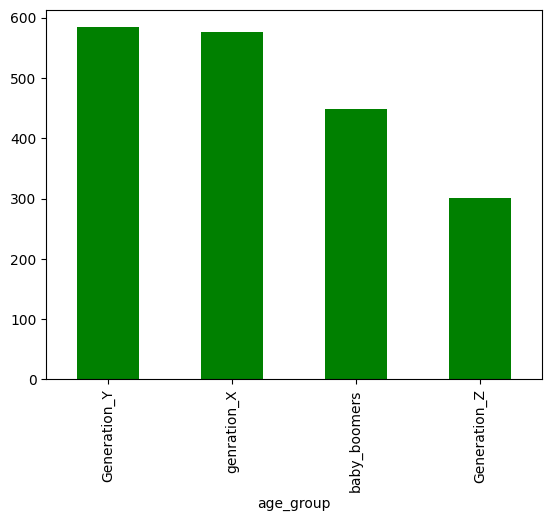

In [63]:
df['age_group'].value_counts().plot(kind='bar', color='green')

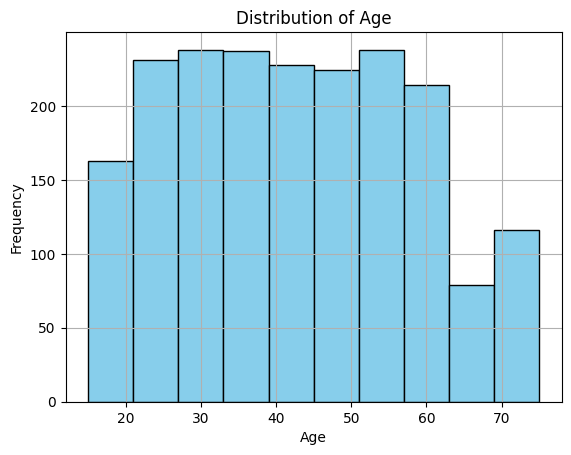

In [64]:
df['age'].hist(bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Corrélation de Pearson :", df['age'].corr(df['salaire'], method='pearson'))
print("Corrélation de Spearman :", df['age'].corr(df['salaire'], method='spearman'))


Corrélation de Pearson : -0.01754980764898643
Corrélation de Spearman : -0.0393511734771309


<Axes: xlabel='ville'>

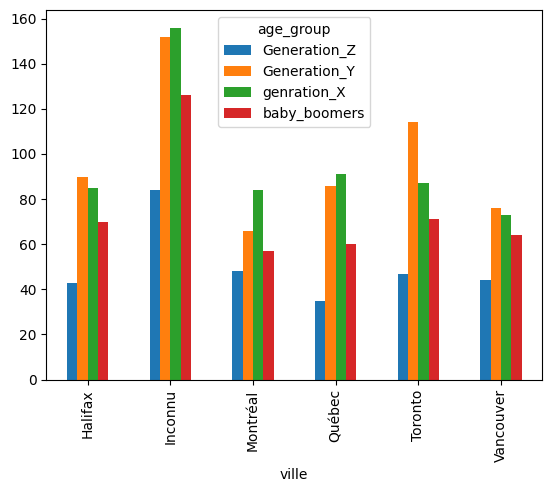

In [66]:
pd.crosstab(df['ville'], df['age_group']).plot(kind='bar')

# coefficient d'asymétrie

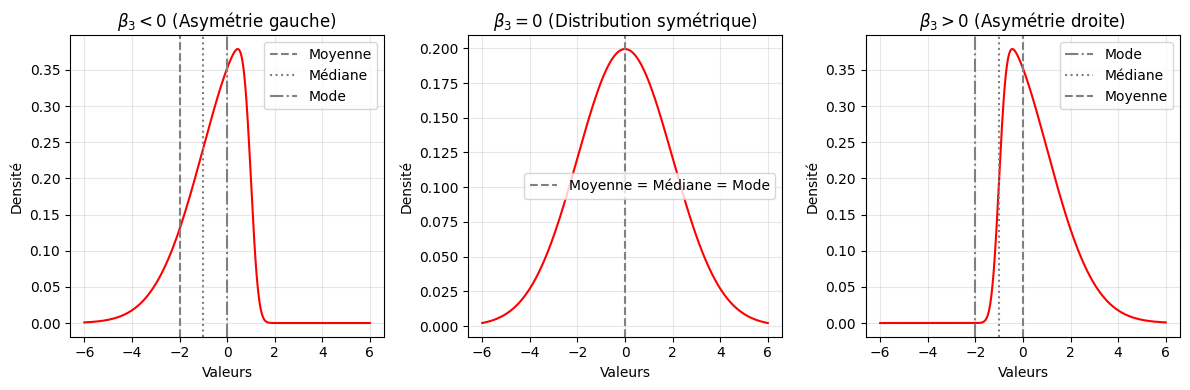

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

# Génération de données asymétriques
x = np.linspace(-6, 6, 1000)
left_skew = skewnorm.pdf(x, -8, loc=1, scale=2)
sym = skewnorm.pdf(x, 0, loc=0, scale=2)
right_skew = skewnorm.pdf(x, 8, loc=-1, scale=2)

# Tracé des trois courbes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# β3 < 0 (asymétrie gauche)
axs[0].plot(x, left_skew, 'r')
axs[0].set_title(r'$\beta_3 < 0$ (Asymétrie gauche)')
axs[0].axvline(-2, color='gray', linestyle='--', label='Moyenne')
axs[0].axvline(-1, color='gray', linestyle=':', label='Médiane')
axs[0].axvline(0, color='gray', linestyle='-.', label='Mode')

# β3 = 0 (symétrique)
axs[1].plot(x, sym, 'r')
axs[1].set_title(r'$\beta_3 = 0$ (Distribution symétrique)')
axs[1].axvline(0, color='gray', linestyle='--', label='Moyenne = Médiane = Mode')

# β3 > 0 (asymétrie droite)
axs[2].plot(x, right_skew, 'r')
axs[2].set_title(r'$\beta_3 > 0$ (Asymétrie droite)')
axs[2].axvline(-2, color='gray', linestyle='-.', label='Mode')
axs[2].axvline(-1, color='gray', linestyle=':', label='Médiane')
axs[2].axvline(0, color='gray', linestyle='--', label='Moyenne')

for ax in axs:
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_xlabel("Valeurs")
    ax.set_ylabel("Densité")

plt.tight_layout()
plt.show()


#coefficient d'aplatissement

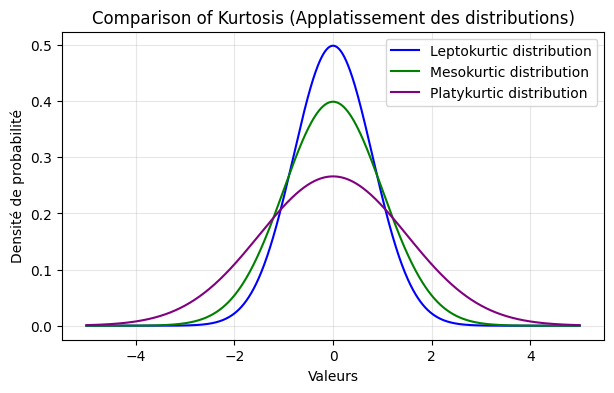

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Génération de données
x = np.linspace(-5, 5, 1000)
# Distributions avec différentes kurtosis
leptokurtic = norm.pdf(x, 0, 0.8)     # Forte pointe
mesokurtic = norm.pdf(x, 0, 1)        # Normale
platykurtic = norm.pdf(x, 0, 1.5)     # Plus aplatie

# Tracer
plt.figure(figsize=(7,4))
plt.plot(x, leptokurtic, color='blue', label='Leptokurtic distribution')
plt.plot(x, mesokurtic, color='green', label='Mesokurtic distribution')
plt.plot(x, platykurtic, color='purple', label='Platykurtic distribution')

# Mise en forme
plt.legend()
plt.title("Comparison of Kurtosis (Applatissement des distributions)")
plt.xlabel("Valeurs")
plt.ylabel("Densité de probabilité")
plt.grid(alpha=0.3)
plt.show()


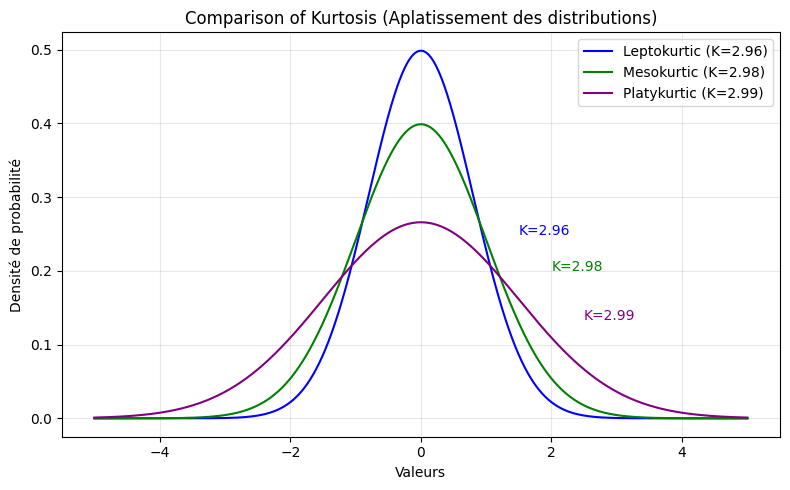

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis

# Génération de données
x = np.linspace(-5, 5, 10000)

# Distributions simulées avec différentes "largeurs"
data_lepto = np.random.normal(0, 0.8, 10000)   # Forte pointe
data_meso = np.random.normal(0, 1, 10000)      # Normale
data_platy = np.random.normal(0, 1.5, 10000)   # Plus aplatie

# Calcul des densités pour affichage
leptokurtic = norm.pdf(x, 0, 0.8)
mesokurtic = norm.pdf(x, 0, 1)
platykurtic = norm.pdf(x, 0, 1.5)

# Calcul des coefficients d’aplatissement
k_lepto = kurtosis(data_lepto, fisher=False)
k_meso = kurtosis(data_meso, fisher=False)
k_platy = kurtosis(data_platy, fisher=False)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(x, leptokurtic, color='blue', label=f'Leptokurtic (K={k_lepto:.2f})')
plt.plot(x, mesokurtic, color='green', label=f'Mesokurtic (K={k_meso:.2f})')
plt.plot(x, platykurtic, color='purple', label=f'Platykurtic (K={k_platy:.2f})')

# Ajouter le texte directement sur les courbes
plt.text(1.5, max(leptokurtic)*0.5, f"K={k_lepto:.2f}", color='blue')
plt.text(2.0, max(mesokurtic)*0.5, f"K={k_meso:.2f}", color='green')
plt.text(2.5, max(platykurtic)*0.5, f"K={k_platy:.2f}", color='purple')

# Mise en forme
plt.legend()
plt.title("Comparison of Kurtosis (Aplatissement des distributions)")
plt.xlabel("Valeurs")
plt.ylabel("Densité de probabilité")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [70]:
import scipy.stats as stats
print( df['age'].skew())

0.2298675187898894


In [71]:
print(df['age'].kurt())

-0.7802815590167427


In [72]:
from scipy import stats
import pandas as pd
# Pour l'excès de kurtosis (recommandé)
excess_kurtosis = stats.kurtosis(df['salaire'])  # DÉFAUT

# Pour le kurtosis complet
true_kurtosis = stats.kurtosis(df['salaire'], fisher=False)
print(round(excess_kurtosis,2),round(true_kurtosis,2))

5.62 8.62


<Axes: >

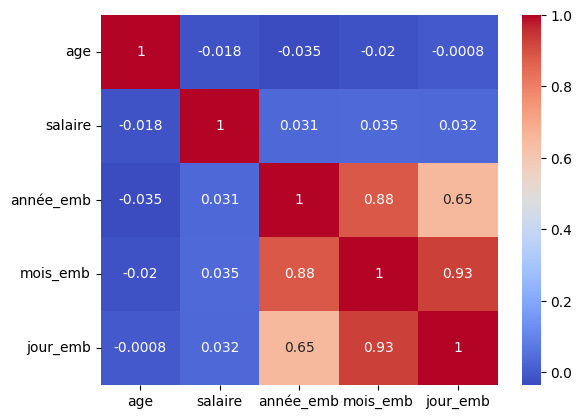

In [73]:
# Select only numeric columns before calculating correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

# ACP , AFC, ACM

In [75]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# On remplace les donnés manquantes par la moyenne
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
numeric_df_imputed = imputer.fit_transform(numeric_df)

# Application de l'ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(numeric_df_imputed)

# On affiche les 5 premieres lignes de l'ACP
print("PCA results (first 5 rows):")
print(X_pca[:5])

PCA results (first 5 rows):
[[-1.21745002e+04  2.16820832e+01]
 [-9.17449993e+03 -1.32846389e+01]
 [-1.21744999e+04 -9.31789600e+00]
 [-8.17449997e+03 -1.27890656e+00]
 [-8.67449992e+03 -6.28388563e+00]]


In [76]:
numeric_df.columns

Index(['age', 'salaire', 'année_emb', 'mois_emb', 'jour_emb'], dtype='object')

/tmp/ipykernel_1108/534516004.py:82: UserWarning: Glyph 32773 (\N{CJK UNIFIED IDEOGRAPH-8005}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1108/534516004.py:82: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1108/534516004.py:83: UserWarning: Glyph 32773 (\N{CJK UNIFIED IDEOGRAPH-8005}) missing from font(s) DejaVu Sans.
  plt.savefig('cercle_correlations.png', dpi=300)
/tmp/ipykernel_1108/534516004.py:83: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.savefig('cercle_correlations.png', dpi=300)


<Figure size 1000x800 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32773 (\N{CJK UNIFIED IDEOGRAPH-8005}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12395 (\N{HIRAGANA LETTER NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


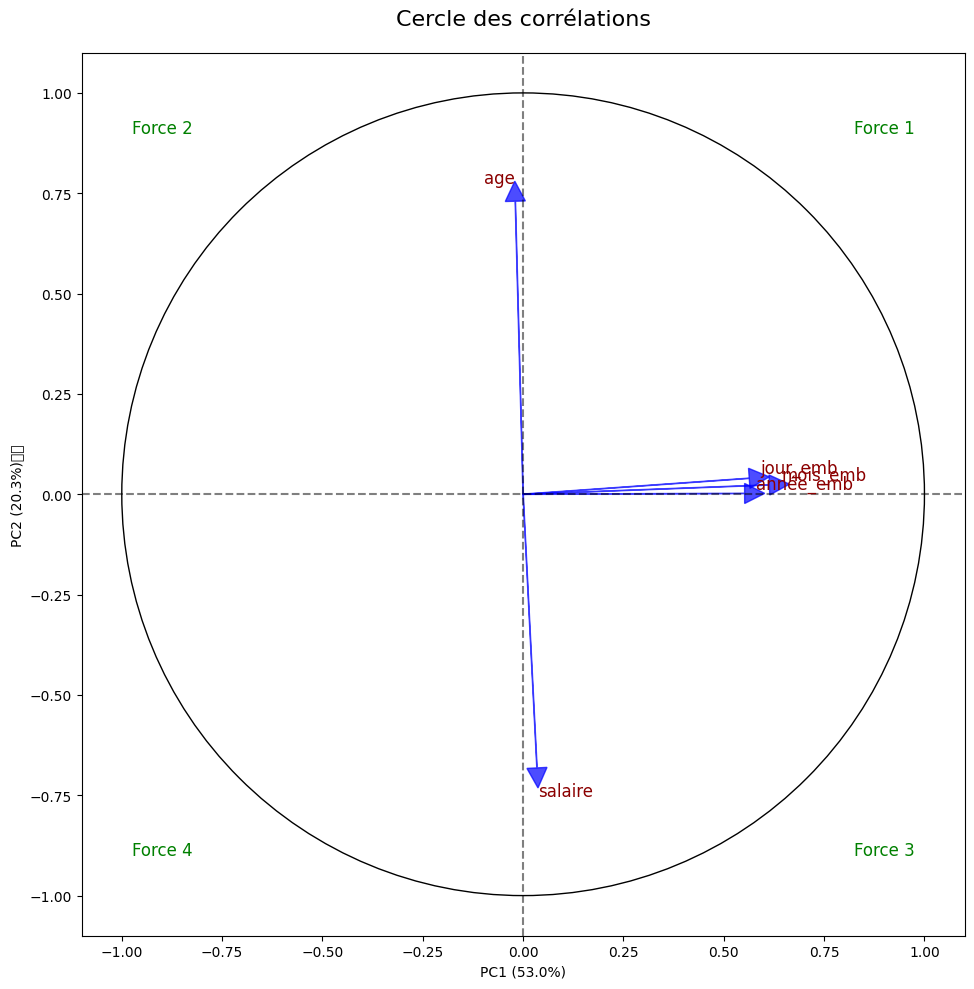

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.font_manager as fm

# Configure font to support CJK characters
try:
    # Try to use a common CJK font available in Colab
    plt.rcParams['font.family'] = ['Noto Sans CJK JP', 'sans-serif']
except Exception:
    # Fallback if the specific font is not found
    plt.rcParams['font.family'] = ['sans-serif']

# 1. Préparation des données
# (Remplacer 'X' par vos données numériques)
scaler = StandardScaler()
X_std = scaler.fit_transform(numeric_df_imputed)

# 2. Exécution de l'ACP
pca = PCA()
pca.fit(X_std)

# 3. Création du cercle des corrélations
def correlation_circle(pca, features, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # Configuration du cercle
    circle = plt.Circle((0, 0), 1, color='k', fill=False)
    ax.add_artist(circle)
    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

    # Ajout des axes
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)

    # Flèches et labels des variables
    n_features = pca.components_.shape[1]
    for i in range(n_features):
        ax.arrow(0, 0,
                 pca.components_[0, i],
                 pca.components_[1, i],
                 head_width=0.05,
                 head_length=0.05,
                 fc='blue',
                 ec='blue',
                 alpha=0.7)

        # Positionnement intelligent des labels
        offset = 1.05
        horizontalalignment = 'right' if pca.components_[0, i] < 0 else 'left'
        verticalalignment = 'top' if pca.components_[1, i] < 0 else 'bottom'

        ax.text(pca.components_[0, i] * offset,
                pca.components_[1, i] * offset,
                features[i],
                fontsize=12,
                ha=horizontalalignment,
                va=verticalalignment,
                color='darkred')

    # Titres et labels
    plt.title("Cercle des corrélations", fontsize=16, pad=20)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)者に")

    # Quadrant d'explication
    plt.text(0.9, 0.9, "Force 1", ha='center', fontsize=12, color='green')
    plt.text(-0.9, 0.9, "Force 2", ha='center', fontsize=12, color='green')
    plt.text(0.9, -0.9, "Force 3", ha='center', fontsize=12, color='green')
    plt.text(-0.9, -0.9, "Force 4", ha='center', fontsize=12, color='green')

    return ax

# 4. Appel de la fonction avec vos noms de variables
# (Remplacer 'feature_names' par vos noms de colonnes)
plt.figure(figsize=(10, 8))
correlation_circle(pca, ['age', 'salaire', 'année_emb', 'mois_emb', 'jour_emb'])
plt.tight_layout()
plt.savefig('cercle_correlations.png', dpi=300)
plt.show()

In [80]:
from sklearn.decomposition import FactorAnalysis
from sklearn.impute import SimpleImputer


In [81]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 5.2 MB/s eta 0:00:00


In [82]:
import prince
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Données mixtes exemple
donnees_mixtes = pd.DataFrame({
    'Age': [25, 32, 45, 28, 51, 36],  # Numérique
    'Salaire': [30000, 45000, 60000, 35000, 75000, 48000],  # Numérique
    'Genre': ['M', 'F', 'M', 'F', 'M', 'F'],  # Catégorielle
    'Education': ['Bac', 'Master', 'Doctorat', 'Licence', 'Master', 'Bac'],  # Catégorielle
    'Ville': ['Paris', 'Lyon', 'Marseille', 'Paris', 'Lyon', 'Toulouse']  # Catégorielle
})

print("Données mixtes:")
print(donnees_mixtes)

Données mixtes:
   Age  Salaire Genre Education      Ville
0   25    30000     M       Bac      Paris
1   32    45000     F    Master       Lyon
2   45    60000     M  Doctorat  Marseille
3   28    35000     F   Licence      Paris
4   51    75000     M    Master       Lyon
5   36    48000     F       Bac   Toulouse


In [89]:
from sklearn.preprocessing import StandardScaler

# Convert numerical columns to float type for FAMD
donnes_mixtes_processed = donnees_mixtes.copy()
donnes_mixtes_processed['Age'] = donnes_mixtes_processed['Age'].astype(float)
donnes_mixtes_processed['Salaire'] = donnes_mixtes_processed['Salaire'].astype(float)

# Standardize numerical columns
scaler = StandardScaler()
donnes_mixtes_processed[['Age', 'Salaire']] = scaler.fit_transform(donnes_mixtes_processed[['Age', 'Salaire']])

# FAMD avec la library prince
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine='sklearn' # Changed from 'auto' to 'sklearn'
)

# Application aux données mixtes
famd.fit(donnes_mixtes_processed)

# Transformation
coordonnees = famd.transform(donnes_mixtes_processed)

print("Coordonnées FACTORIelles:")
print(coordonnees)
print(f"\nInertie expliquée: {famd.eigenvalues_}")

Coordonnées FACTORIelles:
component         0         1
0         -1.836689  0.878885
1          0.110334 -1.799078
2          2.381609  2.529990
3         -2.342848  0.186189
4          2.633729 -1.529595
5         -0.946133 -0.266390

Inertie expliquée: [3.7297159 2.1425431]
